# Task split validation: hierarchical

In [1]:
import sys
sys.path.append('../src')
import utils
import plot_utils

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn import metrics as skm
from sklearn.metrics import r2_score
from sklearn.linear_model import RidgeCV, LinearRegression
import nibabel as nib
from statsmodels.stats.multitest import multipletests

import wbplot
import matplotlib.image as img
import matplotlib.colors as clrs
from matplotlib import colorbar

import matplotlib.pyplot as plt

from brainsmash.mapgen.base import Base
from brainsmash.mapgen.stats import pearsonr, pairwise_r
from brainsmash.mapgen.stats import nonparp

import RSMtools
import plottools

from tqdm import tqdm

In [2]:
projDir = '/home/ln275/f_mc1689_1/multitask_generalization/'
intermFilesDir = projDir + 'data/derivatives/local_upload/'
helpfiles_dir = projDir + 'docs/experimentfiles/'
subProjDir = projDir + 'data/derivatives/RSM_ActFlow/'
figoutdir = projDir + 'docs/figures/working/activeVisual_actflow/'
fcdir = projDir + 'data/derivatives/FC_new/'

In [3]:
subIDs=['02','03','06','08','10','12','14','18','20',
        '22','24','25','26','27','28','29','30','31']

onlyRestSubIdx = [ 0, 1, 3, 4, 6, 7, 8,10,11,
                  12,20,13,21,14,22,15,23,16] # Use when dealing with full subjects' data (n=24)

nSub = len(subIDs)

glasserfilename = helpfiles_dir + 'Q1-Q6_RelatedParcellation210.LR.CorticalAreas_dil_Colors.32k_fs_RL.dlabel.nii'
glasser = np.squeeze(nib.load(glasserfilename).get_fdata())

In [4]:
nTaskCond = 44
nParcels = 360
nSessions = 2

# Reading in task metadata

taskCond_df = pd.read_csv(intermFilesDir + 'hierarchicaltaskconditions.csv')

TaskCondIdx_subsetFromActiveVisual96 = np.array(taskCond_df['selectFromActiveVisual96'].values)
TaskIdx = np.array(taskCond_df['TaskIndex'].values)
TaskDemandIdx = np.array(taskCond_df['taskLoad'].values)

In [5]:
# Reading parcel-level FC

with open(fcdir + 'allSubFC_parCorr.pkl', 'rb') as f:
    allSubParCorr = pickle.load(f)

In [6]:
# Reading in FC gradients

gradients = np.load(fcdir + 'meansub_FCgrad_3PCs_0.8thr.npy')

In [7]:
# Reading in task metadata

TaskDemandIdx = np.array(taskCond_df['taskLoad'].values)
respkeys_arr = taskCond_df['Key'].values
stimType1 = taskCond_df['stimType1'].values
stimType2 = taskCond_df['stimType2'].values
stimType_sameflag = taskCond_df['stimType_sameflag'].values

In [8]:
# Generate base theoretical RSMs (stim, motor, task)

# Task demand RSM
theoTaskRSM = np.zeros((nTaskCond,nTaskCond))
for taskCondA in range(nTaskCond):
    for taskCondB in range(nTaskCond):

        if taskCondA>=taskCondB: 
            continue

        theoTaskRSM[taskCondA,taskCondB] = 3 - np.abs(TaskDemandIdx[taskCondA]-TaskDemandIdx[taskCondB])

theoTaskRSM = theoTaskRSM + theoTaskRSM.T
np.fill_diagonal(theoTaskRSM,3*np.ones(nTaskCond))

# Motor RSM
theoMotorRSM = np.zeros((nTaskCond,nTaskCond))
for taskCondA in range(nTaskCond):
    for taskCondB in range(nTaskCond):

        if taskCondA>=taskCondB: 
            continue

        if respkeys_arr[taskCondA]==respkeys_arr[taskCondB]:
            theoMotorRSM[taskCondA,taskCondB] = 1

        if respkeys_arr[taskCondA]=='all':
            theoMotorRSM[taskCondA,:] = 1

theoMotorRSM = theoMotorRSM + theoMotorRSM.T
np.fill_diagonal(theoMotorRSM,1*np.ones(nTaskCond))

# Stimulus RSM

theoStimRSM = np.zeros((nTaskCond,nTaskCond))
for taskCondA in range(nTaskCond):
    for taskCondB in range(nTaskCond):

        if taskCondA>=taskCondB: 
            continue

        if stimType1[taskCondA] == stimType1[taskCondB]:
            if stimType2[taskCondA] == stimType2[taskCondB]:
                if stimType_sameflag[taskCondA]==stimType_sameflag[taskCondB]:
                    theoStimRSM[taskCondA,taskCondB] = 3
                else:
                    theoStimRSM[taskCondA,taskCondB] = 2
            else:
                theoStimRSM[taskCondA,taskCondB] = 1
        else:
            theoStimRSM[taskCondA,taskCondB] = 0

theoStimRSM = theoStimRSM + theoStimRSM.T
np.fill_diagonal(theoStimRSM,3*np.ones(nTaskCond))

In [9]:
# Generate conjunction RSMs

theoStimRSM = theoStimRSM/np.max(theoStimRSM)
theoTaskRSM = theoTaskRSM/np.max(theoTaskRSM)
theoMotorRSM = theoMotorRSM/np.max(theoMotorRSM)

theoStimTaskMotorRSM = theoStimRSM * theoTaskRSM * theoMotorRSM

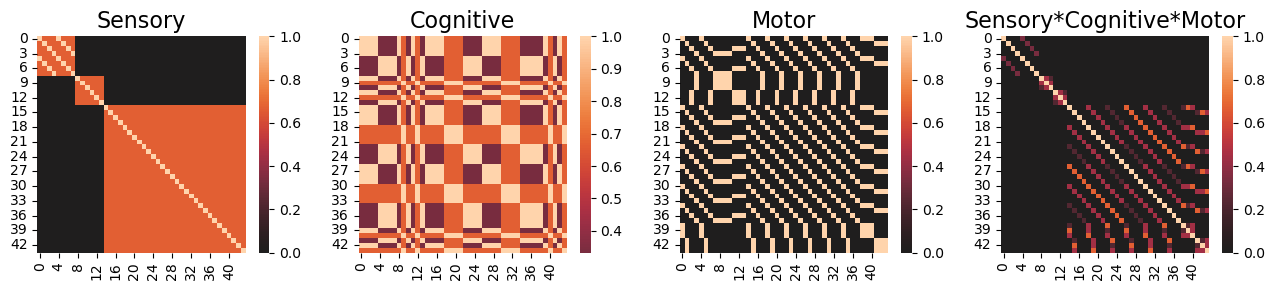

In [63]:
# Plot theoretical RSMs

fig,ax = plt.subplots(1, 4, figsize=(13,3))
ax1, ax2, ax3,ax4 = ax.flatten()

# Stimulus
sns.heatmap(theoStimRSM,center=0,ax=ax1)
ax1.set_title('Sensory', fontsize=16)

# Task
sns.heatmap(theoTaskRSM,center=0,ax=ax2)
ax2.set_title('Cognitive', fontsize=16)

# Motor
sns.heatmap(theoMotorRSM,center=0,ax=ax3)
ax3.set_title('Motor', fontsize=16)

# Stim*Task*Motor
sns.heatmap(theoStimTaskMotorRSM,center=0,ax=ax4)
ax4.set_title('Sensory*Cognitive*Motor', fontsize=16)

plt.subplots_adjust(wspace=0.7)

plt.tight_layout()

plt.savefig(figoutdir + 'theoRSMs.pdf',transparent=True)
plt.show()

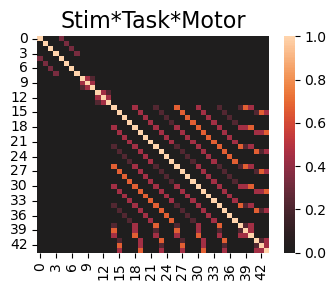

In [79]:
fig,ax = plt.subplots(figsize=(3.5,3))

# Stim*Task*Motor
sns.heatmap(theoStimTaskMotorRSM,center=0)
ax.set_title('Stim*Task*Motor', fontsize=16)

plt.tight_layout()

plt.savefig(figoutdir + 'theoRSMs_conjunction.pdf')
plt.show()

In [10]:
# Reading observed RSMs

with open(subProjDir + 'allsub_taskCond_RSM_activeVisual.pkl', 'rb') as f:
    allsub_taskCondRSM = pickle.load(f)
    
select_sub_taskCondRSM = allsub_taskCondRSM[onlyRestSubIdx,:,:,:][:,:,TaskCondIdx_subsetFromActiveVisual96,:][:,:,:,TaskCondIdx_subsetFromActiveVisual96]

print('select_sub_taskCondRSM.shape',select_sub_taskCondRSM.shape)

select_sub_taskCondRSM.shape (18, 360, 44, 44)


In [14]:
# Running regression

X_reg = np.hstack([theoStimRSM.flatten().reshape(-1,1),
                   theoTaskRSM.flatten().reshape(-1,1),
                   theoMotorRSM.flatten().reshape(-1,1),
                   theoStimTaskMotorRSM.flatten().reshape(-1,1)])

nRegressors = X_reg.shape[1]

regNames = ['Sensory','Cognitive','Motor','Sensory*Cognitive*Motor']

In [39]:
allsub_coef = np.zeros((nSub,nParcels,nRegressors))
allsub_r2 = np.zeros((nSub,nParcels))

for subIdx in range(nSub):
    print(subIdx)
    for roiIdx in range(nParcels):

        y = select_sub_taskCondRSM[subIdx,roiIdx,:,:].flatten().reshape(-1,1)
        
        model = RidgeCV(cv=5)
        model.fit(X_reg, y)

        allsub_coef[subIdx,roiIdx,:] = model.coef_[0]

        y_pred = model.predict(X_reg)

        allsub_r2[subIdx,roiIdx] = r2_score(y, y_pred)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


In [40]:
with open(subProjDir + 'TaskSplitRSA_allsub_coef.pkl', 'wb') as f:
    pickle.dump(allsub_coef,f)

In [10]:
# Reading back

with open(subProjDir + 'TaskSplitRSA_allsub_coef.pkl', 'rb') as f:
    allsub_coef = pickle.load(f)

In [21]:
# Computing meansub coef

meansub_coef = np.mean(allsub_coef,axis=0)
meansub_coef_survived = meansub_coef
allsub_coef_survived = allsub_coef

In [12]:
sensory_roi_id,association_roi_id,motor_roi_id,_,_ = RSMtools.getBSwise_ROIid()

In [15]:
top10_coef_roiIdx = np.zeros((10,4))
top10_coef_roiIdx_BScount = np.zeros((3,4))
for regIdx in range(nRegressors):
    top10_coef_roiIdx[:,regIdx] = np.argsort(meansub_coef_survived[:,regIdx])[-10:][::-1]
    
    top10_coef_roiIdx_BScount[0,regIdx] = np.sum(np.isin(top10_coef_roiIdx[:,regIdx], sensory_roi_id))
    top10_coef_roiIdx_BScount[1,regIdx] = np.sum(np.isin(top10_coef_roiIdx[:,regIdx], association_roi_id))
    top10_coef_roiIdx_BScount[2,regIdx] = np.sum(np.isin(top10_coef_roiIdx[:,regIdx], motor_roi_id))

In [16]:
top10_coef_roiIdx_BScount

array([[9., 3., 3., 9.],
       [1., 7., 0., 0.],
       [0., 0., 7., 1.]])

In [17]:
np.argmax(meansub_coef_survived[:,0])

317

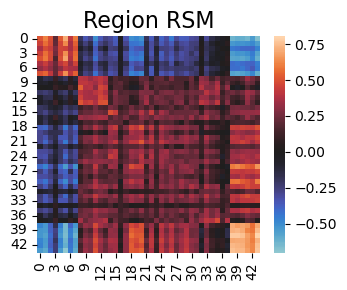

In [67]:
# Plotting example neural RSM (picking top sensory region)

meansub_taskCondRSM = np.mean(select_sub_taskCondRSM,axis=0)

fig,ax = plt.subplots(figsize=(3.5,3))

sns.heatmap(meansub_taskCondRSM[317,:,:],center=0)
ax.set_title('Region RSM', fontsize=16)

plt.tight_layout()

plt.savefig(figoutdir + 'neuralRSM_example.pdf')
plt.show()

pixdim[1,2,3] should be non-zero; setting 0 dims to 1

Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.flat.32k_fs_LR.surf.gii was 0.040817 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.inflated_MSMAll.32k_fs_LR.surf.gii was 0.017155 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.024911 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.014928 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.flat.32k_fs_LR.surf.gii was 0.041544 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.inflated_MSMAll.32k_fs_LR.surf.gii was 0.016052 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.025866 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.014778 seconds.


Info:

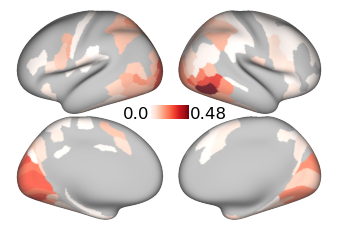

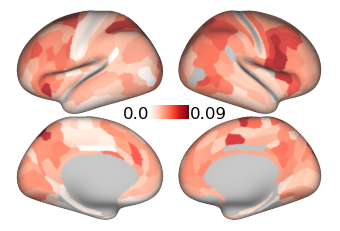

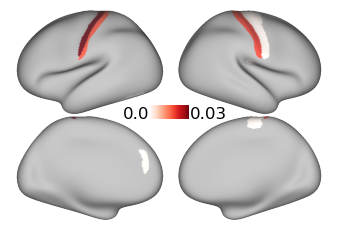

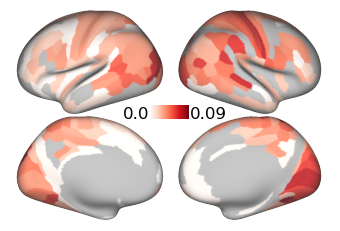

In [51]:
for regIdx in range(nRegressors):
    this_term_survived = meansub_coef_survived[:,regIdx]
    this_term_survived = np.where(this_term_survived>0,this_term_survived,0)

    inputdata = this_term_survived
    file_out = 'TaskSplitRSA_MeanSubCoef_' + regNames[regIdx]
    title = None

    plot_utils.get_brain_plot(inputdata,file_out,title,ignore_unvalid=False)

In [19]:
# Correlating with expansion

# Reading dimdiff (positive values are expansion)
with open(subProjDir + 'allsub_dim_diff.pkl', 'rb') as f:
    dim_diff = pickle.load(f)
    
meansub_dim_diff = np.mean(dim_diff,axis=0)

In [22]:
# Across subject significance

allSub_r_full = np.zeros((nRegressors,nSub))

for regIdx in range(nRegressors):

    coef_survived = meansub_coef_survived[:,regIdx]
    survived = coef_survived!=0

    X = dim_diff[:,survived]
    Y = allsub_coef_survived[:,survived,regIdx]

    for subIdx in range(nSub):

        r_full,p1 = stats.pearsonr(X[subIdx,:],Y[subIdx,:])
        allSub_r_full[regIdx,subIdx] = r_full

    t_full,p_full = stats.ttest_1samp(np.arctanh(allSub_r_full[regIdx,:]), popmean=0, axis=0)
    
    print(regNames[regIdx],': t(17)=',t_full,' p=',p_full)

Sensory : t(17)= 12.14104080985182  p= 8.413437964524506e-10
Cognitive : t(17)= 2.758158481973974  p= 0.013436159190413717
Motor : t(17)= -3.5529967363424784  p= 0.002446095317709859
Sensory*Cognitive*Motor : t(17)= 8.130955550877983  p= 2.923939326070273e-07


In [23]:
# Comparing correlation with conjunction against correlation with other terms:

for regIdx in range(nRegressors-1):

    t_reg_against_conj,p_reg_against_conj = stats.ttest_rel(np.arctanh(allSub_r_full[3,:]),np.arctanh(allSub_r_full[regIdx,:]), axis=0)
    print('r_conj vs. r_',regNames[regIdx], ': t(17)=',t_reg_against_conj,' p=',p_reg_against_conj)

r_conj vs. r_ Sensory : t(17)= -1.94364919996906  p= 0.06868154357438129
r_conj vs. r_ Cognitive : t(17)= 2.736637083811429  p= 0.01405606178656832
r_conj vs. r_ Motor : t(17)= 6.560181583405239  p= 4.856182515516643e-06


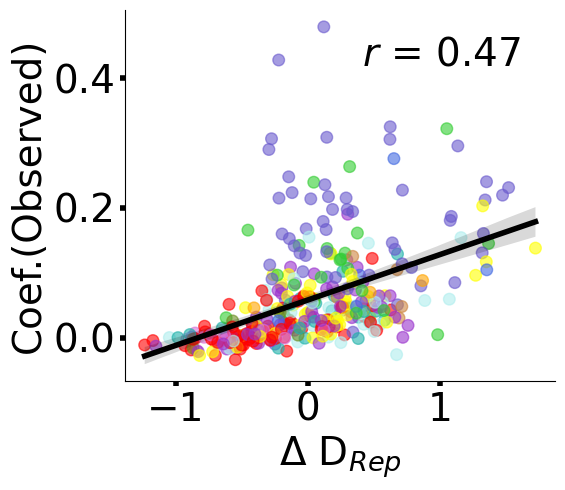

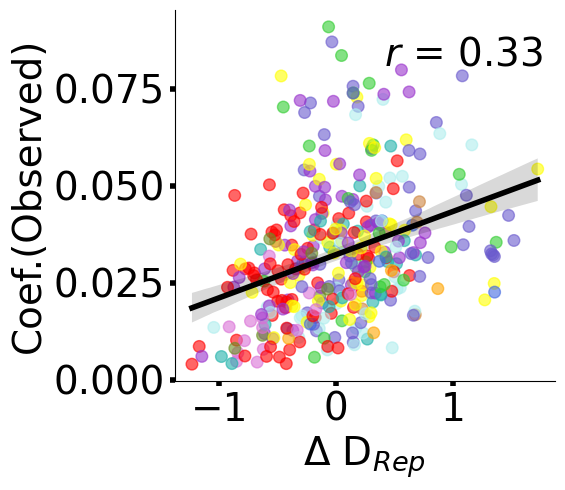

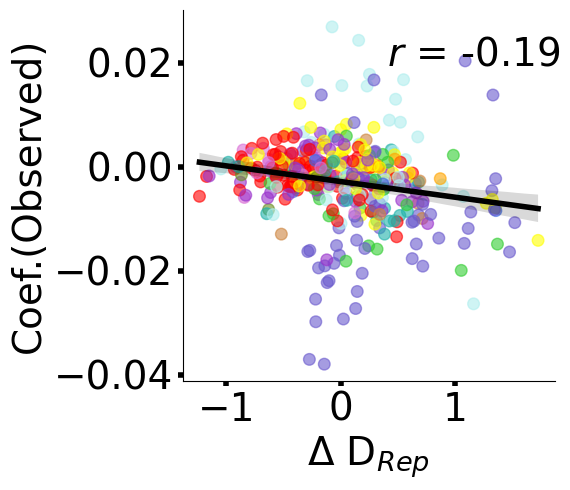

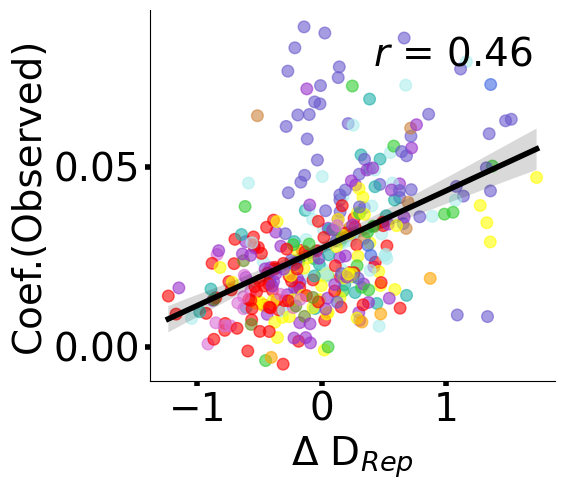

In [27]:
for regIdx in range(nRegressors):

    coef_survived = meansub_coef_survived[:,regIdx]

    X = meansub_dim_diff
    Y = coef_survived
    RAaxis = 'full'
    xlabel = r'Δ D$_{Rep}$'
    ylabel = 'Coef.(Observed)'
    outname = figoutdir + 'TaskSplitRSA_Coef_vs_Expansion_' + regNames[regIdx] + '.pdf'

    plottools.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TR',xmin=None,xmax=None,ymin=None,ymax=None,
                                custom_select=None,invert_xaxis=False,deg=1,xtickbins=4,ytickbins=4,
                                plotwidth=5.75,showstat=True,regplot=True)

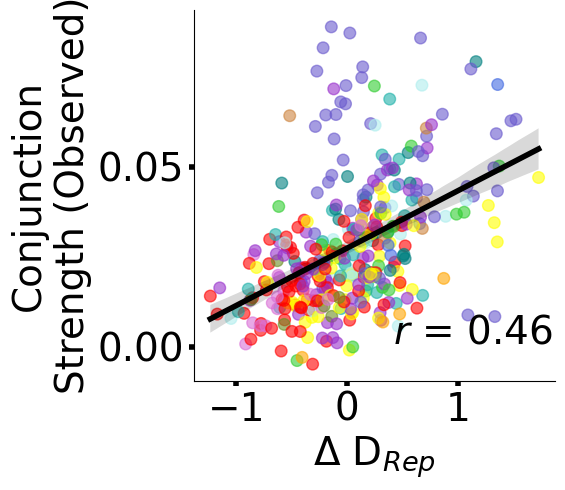

In [45]:
# ConjunctionStrength vs. DimensionalityDifference

X = meansub_dim_diff
Y = meansub_coef[:,3]
RAaxis = 'full'
xlabel = r'Δ D$_{Rep}$'
ylabel = 'Conjunction\nStrength (Observed)'
outname = figoutdir + 'obs_conjunctionstrength_vs_dimdiff.pdf'

plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='BR',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=3,
                            plotwidth=5.75,showstat=True)
plt.show()

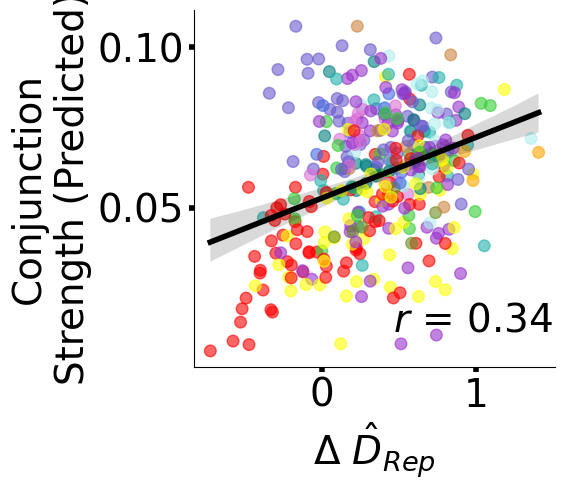

In [46]:
# Predicted ConjunctionStrength vs. DimensionalityDifference

X = meansub_dim_diff_pred
Y = meansub_coef_pred[:,3]
RAaxis = 'full'
xlabel = r'Δ $\hat{D}_{Rep}$'
ylabel = 'Conjunction\nStrength (Predicted)'
outname = figoutdir + 'pred_conjunctionstrength_vs_dimdiff.pdf'

plot_utils.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='BR',ymin=None,ymax=None,xmin=None,xmax=None,
                            invert_xaxis=False,deg=1,xtickbins=3,ytickbins=3,
                            plotwidth=5.75,showstat=True)
plt.show()

## Re-running regression with actflow pred data 

In [12]:
with open(subProjDir + 'allsub_taskCond_RSM_activeVisual_actflowpred_PCR_CVoptimal.pkl', 'rb') as f1:
    allsub_predRSM = pickle.load(f1)

In [13]:
allsub_predRSM.shape

(18, 360, 96, 96)

In [14]:
allsub_predRSM_select = allsub_predRSM[:,:,TaskCondIdx_subsetFromActiveVisual96,:][:,:,:,TaskCondIdx_subsetFromActiveVisual96]

allsub_predRSM_select.shape

(18, 360, 44, 44)

In [61]:
allsub_coef_pred = np.zeros((nSub,nParcels,nRegressors))
allsub_r2_pred = np.zeros((nSub,nParcels))

for subIdx in range(nSub):
    print(subIdx)
    for roiIdx in range(nParcels):

        y = allsub_predRSM_select[subIdx,roiIdx,:,:].flatten().reshape(-1,1)
        
        model = RidgeCV(cv=5)
        model.fit(X_reg, y)

        allsub_coef_pred[subIdx,roiIdx,:] = model.coef_[0]

        y_pred = model.predict(X_reg)

        allsub_r2_pred[subIdx,roiIdx] = r2_score(y, y_pred)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


In [62]:
with open(subProjDir + 'TaskSplitRSA_allsub_coef_actflowpred.pkl', 'wb') as f:
    pickle.dump(allsub_coef_pred,f)

In [28]:
with open(subProjDir + 'TaskSplitRSA_allsub_coef_actflowpred.pkl', 'rb') as f:
    allsub_coef_pred = pickle.load(f)

In [29]:
# Computing meansub coef only in stats surviving regions

meansub_coef_pred = np.mean(allsub_coef_pred,axis=0)
allsub_coef_pred_survived = allsub_coef_pred
meansub_coef_pred_survived = meansub_coef_pred

In [20]:
# Connperm null coef

with open(subProjDir + 'allsub_tasksplitRSA_connperm_coef.pkl', 'rb') as f:
    allsub_coef_pred_connperm = pickle.load(f)
    
allsub_coef_pred_connperm.shape

(18, 360, 4, 100)

In [21]:
# Generate 1000 group-level means by bootstrapping

nPerm = 100
n_groupnull = 1000
meansub_coef_pred_connperm = np.zeros((nParcels,nRegressors,n_groupnull))

for groupnullIdx in range(n_groupnull):
    
    this_groupiter_connperm_coef_pred = []

    for subIdx in range(nSub):

        this_groupiter_connperm_coef_pred.append(allsub_coef_pred_connperm[subIdx,:,:,np.random.randint(0, nPerm)])

    meansub_coef_pred_connperm[:,:,groupnullIdx] = np.mean(np.array(this_groupiter_connperm_coef_pred),axis=0)
    
meansub_coef_pred_connperm.shape

(360, 4, 1000)

In [22]:
survivedIdx_expanded = np.tile(allreg_rejected_pred[:, :, np.newaxis], (1, 1, 1000))
meansub_coef_pred_connperm_survived = meansub_coef_pred_connperm * survivedIdx_expanded

In [23]:
meansub_coef_pred_connperm_survived.shape

(360, 4, 1000)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1

Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.flat.32k_fs_LR.surf.gii was 0.046326 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.inflated_MSMAll.32k_fs_LR.surf.gii was 0.018526 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.026615 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.L.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.015636 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.flat.32k_fs_LR.surf.gii was 0.041291 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.inflated_MSMAll.32k_fs_LR.surf.gii was 0.018878 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.midthickness_MSMAll.32k_fs_LR.surf.gii was 0.027609 seconds.


Info: Time to read /tmp/HumanCorticalParcellations/S1200.R.very_inflated_MSMAll.32k_fs_LR.surf.gii was 0.015712 seconds.


Info:

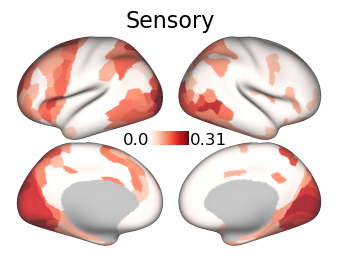

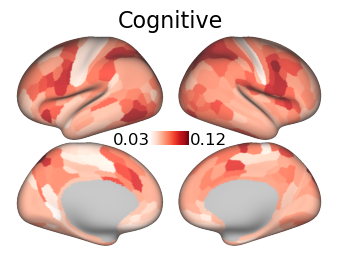

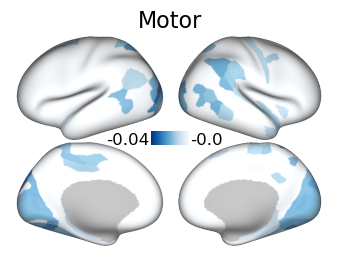

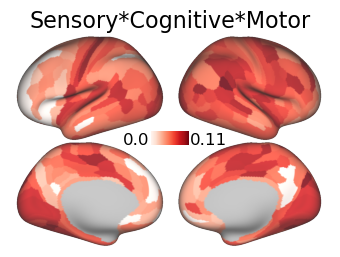

In [24]:
for regIdx in range(nRegressors):

    filename_string = 'TaskSplitRSA_MeanSubCoef_actflowpred' + regNames[regIdx]
    inputdata = meansub_coef_pred_survived[:,regIdx]

    file_out = figoutdir + filename_string + '.png'

    # flip hemispheres, since CAB-NP is ordered left-to-right, while wbplot uses right-to-left
    inputdata_flipped=np.zeros(np.shape(inputdata))
    inputdata_flipped[0:180]=inputdata[180:360]
    inputdata_flipped[180:360]=inputdata[0:180]

    # Set to all reds if no negative values
    if min(inputdata) >= 0:
        colormap='Reds'
        vmin, vmax = np.min(inputdata), np.max(inputdata)
    elif max(inputdata) <= 0:
        colormap='Blues_r'
        vmin, vmax = np.min(inputdata), np.max(inputdata)
    else:
        colormap='seismic'
        limit = np.max([np.abs(np.min(inputdata)), np.abs(np.max(inputdata))])
        vmin,vmax = -1*limit, limit

    wbplot.pscalar(
            file_out=file_out,
            pscalars=inputdata_flipped,
            vrange = (vmin, vmax),
            cmap=colormap,
            transparent=True)


    plt.figure(figsize=(3.5,3))
    ax = plt.subplot(111)
    im = img.imread(file_out) 
    plt.imshow(im)
    plt.axis('off')
    plt.title(regNames[regIdx],fontsize=16)

    cnorm = clrs.Normalize(vmin=vmin, vmax=vmax)  # only important for tick placing
    cmap = plt.get_cmap(colormap)
    cax = ax.inset_axes([0.44, 0.48, 0.12, 0.07])
    cbar = colorbar.ColorbarBase(
        cax, cmap=cmap, norm=cnorm, orientation='horizontal')
    #cbar.set_ticks([-2, 2])  # don't need to do this since we're going to hide them
    cax.get_xaxis().set_tick_params(length=0, pad=-2)
    cbar.set_ticklabels([])
    cbar.outline.set_visible(False)
    cax.text(-0.025, 0.4, str(round(vmin,2)), ha='right', va='center', transform=cax.transAxes,
             fontsize=12);
    cax.text(1.025, 0.4, str(round(vmax,2)), ha='left', va='center', transform=cax.transAxes,
             fontsize=12);
    plt.tight_layout()
    plt.savefig(figoutdir + filename_string + '.pdf',transparent=True)

## Against actflow pred dimdiff

In [30]:
# Actflow pred dimensionality
with open(subProjDir + 'allsub_dimensionality_activeVisual_actflowpred_PCR_CVoptimal.pkl', 'rb') as f:
    allsub_dimensionality = pickle.load(f)

In [31]:
# Observed dimensionality

with open(subProjDir + 'allsub_dimensionality_activeVisual_observed_18sub.pkl', 'rb') as f:
    allsub_obs_dimensionality = pickle.load(f)

In [32]:
meansub_pred_dim = np.mean(allsub_dimensionality,axis=0)

In [29]:
dim_diff_pred = np.zeros((nSub,nParcels))

for subIdx in range(nSub):
    
    for targetroi_idx in range(nParcels):

        # get connected regions indices
        connected_regionsIdx = np.where(allSubParCorr[subIdx,targetroi_idx,:]!=0)[0]
        
        # get mean dimensionality of connected regions (use observed dimensionality here)
        mean_connreg_dim = np.mean(allsub_obs_dimensionality[subIdx,connected_regionsIdx])
        dim_diff_pred[subIdx,targetroi_idx] = allsub_dimensionality[subIdx,targetroi_idx] - mean_connreg_dim
        
with open(subProjDir + 'allsub_dim_diff_pred.pkl', 'wb') as f:
    pickle.dump(dim_diff_pred,f)

In [33]:
with open(subProjDir + 'allsub_dim_diff_pred.pkl', 'rb') as f:
    dim_diff_pred = pickle.load(f)

In [34]:
meansub_dim_diff_pred = np.mean(dim_diff_pred,axis=0)

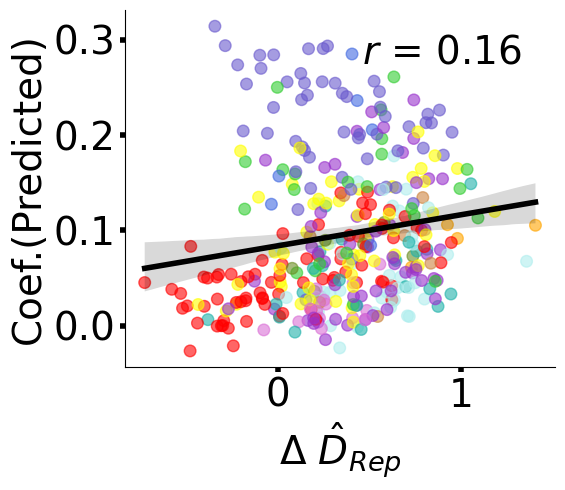

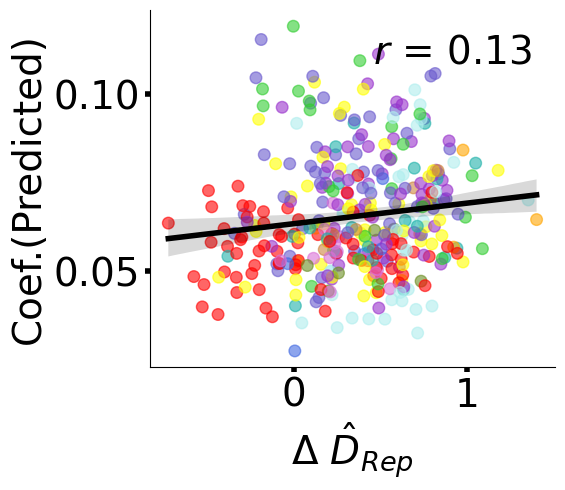

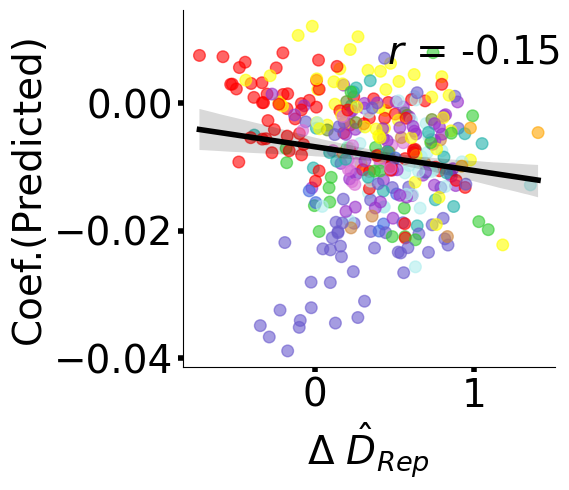

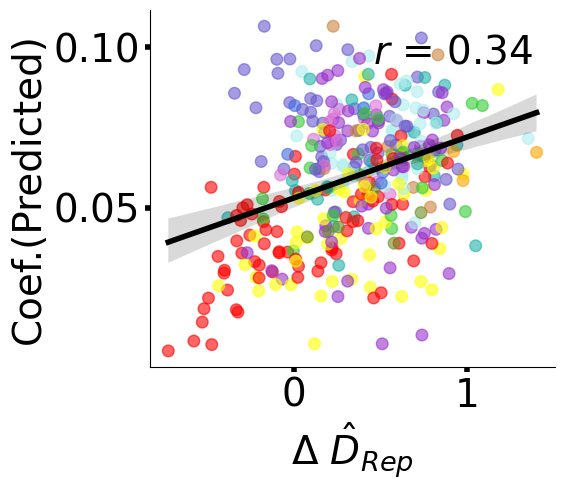

In [42]:
for regIdx in range(nRegressors):

    coef_survived = meansub_coef_pred_survived[:,regIdx]

    X = meansub_dim_diff_pred
    Y = coef_survived
    RAaxis = 'full'
    xlabel = r'Δ $\hat{D}_{Rep}$'
    ylabel = 'Coef.(Predicted)'
    outname = figoutdir + 'TaskSplitRSA_Pred_Coef_vs_Expansion_' + regNames[regIdx] + '.pdf'

    plottools.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TR',xmin=None,xmax=None,ymin=None,ymax=None,
                                custom_select=None,invert_xaxis=False,deg=1,xtickbins=4,ytickbins=4,
                                plotwidth=5.75,showstat=True,regplot=True)

In [40]:
# # Across subject significance
    
allSub_r_full = np.zeros((nRegressors,nSub))

for regIdx in range(nRegressors):

    coef_survived = meansub_coef_pred_survived[:,regIdx]
    survived = coef_survived!=0

    X = dim_diff_pred[:,survived]
    Y = allsub_coef_pred[:,survived,regIdx]

    for subIdx in range(nSub):

        r_full,p1 = stats.pearsonr(X[subIdx,:],Y[subIdx,:])
        allSub_r_full[regIdx,subIdx] = r_full

    t_full,p_full = stats.ttest_1samp(np.arctanh(allSub_r_full[regIdx,:]), popmean=0, axis=0)
    
    print(regNames[regIdx],': t(17)=',t_full,' p=',p_full)

Sensory : t(17)= 3.5681381090980873  p= 0.002367042517129994
Cognitive : t(17)= 0.48172185810673424  p= 0.6361464209296336
Motor : t(17)= -2.2335174972690006  p= 0.03924284188341261
Sensory*Cognitive*Motor : t(17)= 3.5188594976923047  p= 0.002634093834065963


In [41]:
# Comparing correlation with conjunction against correlation with other terms:

for regIdx in range(nRegressors-1):

    t_reg_against_conj,p_reg_against_conj = stats.ttest_rel(np.arctanh(allSub_r_full[3,:]),np.arctanh(allSub_r_full[regIdx,:]), axis=0)
    print('r_conj vs. r_',regNames[regIdx], ': t(17)=',t_reg_against_conj,' p=',p_reg_against_conj)

r_conj vs. r_ Sensory : t(17)= -0.4537498174509421  p= 0.6557479421868473
r_conj vs. r_ Cognitive : t(17)= 1.7490782015574098  p= 0.09830797825918362
r_conj vs. r_ Motor : t(17)= 3.1274698319642416  p= 0.0061324980884548755


In [38]:
conj_expansion_pred_corr_obs, _ = stats.pearsonr(dimdiff_survived[survived], coef_survived[survived])

conj_expansion_pred_corr_obs

0.2678744183394182

In [39]:
# permutation significance
# using 'survived' from above, as restricting to the same regions

regIdx = 3

dimdiff_survived = allreg_rejected_pred[:,regIdx]*meansub_dim_diff_pred

conj_expansion_pred_corr_null = np.zeros(n_groupnull)
for groupnullIdx in range(n_groupnull):

    coef_survived_connperm = meansub_coef_pred_connperm_survived[:,regIdx,groupnullIdx]

    conj_expansion_pred_corr_null[groupnullIdx], _ = stats.pearsonr(dimdiff_survived[survived], coef_survived_connperm[survived])
    # conj_expansion_pred_corr_null[groupnullIdx], _ = stats.pearsonr(dimdiff_survived[survived],np.random.rand(np.sum(survived))-0.5)

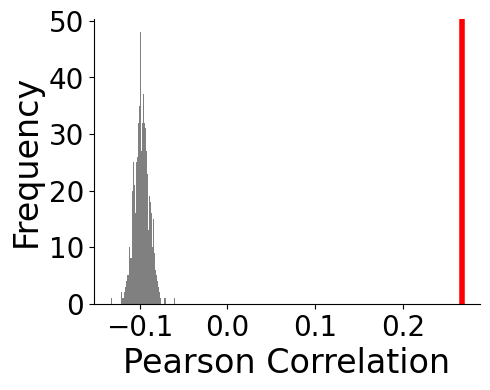

In [41]:
fig,ax = plt.subplots(figsize=(5,4))
plt.hist(conj_expansion_pred_corr_null,bins=100,color='gray')
plt.axvline(x=conj_expansion_pred_corr_obs, color='red',linewidth=4)

plt.xticks(fontsize=20)
plt.locator_params(axis='x', nbins=5)
plt.yticks(fontsize=20)

#plt.title('Null Distributions and Observed Values (Sorted by Observed Means)')
plt.ylabel('Frequency',fontsize=24)
plt.xlabel('Pearson Correlation',fontsize=24)
# plt.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig(figoutdir + 'Actflow_TaskSplitRSA_Conj_vs_PredDimdiff_wConnPerm.pdf',transparent=True)

plt.show()

## Dimensionality of observed 44x44 matrices

In [24]:
select_sub_taskCondRSM.shape

(18, 360, 44, 44)

In [32]:
obsdim_tasksplit = np.zeros((nSub,nParcels))
preddim_tasksplit = np.zeros((nSub,nParcels))

for subIdx in range(nSub):
    for roiIdx in range(nParcels):
        thisRSM = select_sub_taskCondRSM[subIdx,roiIdx,:,:]
        thisRSM_pred = allsub_predRSM[subIdx,roiIdx,:,:]
        
        obsdim_tasksplit[subIdx,roiIdx] = RSMtools.getDimensionality(thisRSM)
        preddim_tasksplit[subIdx,roiIdx] = RSMtools.getDimensionality(thisRSM_pred)

In [26]:
meansub_obsdim_tasksplit = np.mean(obsdim_tasksplit,axis=0)

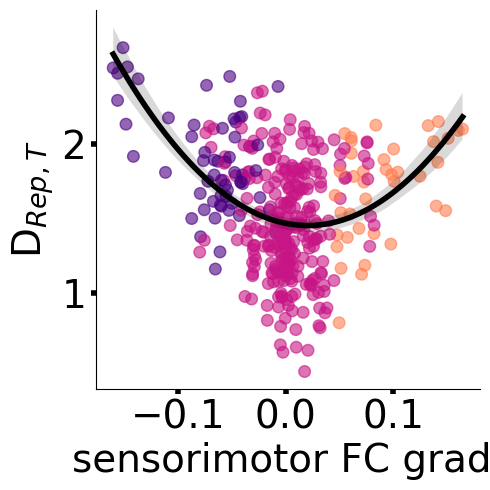

In [27]:
X = gradients[:,1]
Y = meansub_obsdim_tasksplit
RAaxis = 'full_BS'
xlabel = 'sensorimotor FC grad.'
ylabel = r'D$_{Rep,T}$'
outname = figoutdir + 'taskSplit_obsdim_vs_grad2.pdf'

plottools.customScatterPlot(X,Y,RAaxis,xlabel,ylabel,outname,legLoc='TL',xmin=None,xmax=None,ymin=None,ymax=None,
                            invert_xaxis=False,deg=2,xtickbins=3,ytickbins=3,
                            plotwidth=5,showstat=False,regplot=True)

In [33]:
# Computing dimdiff for 44 task conditions only

dim_diff_tasksplit = np.zeros((nSub,nParcels))
mean_connreg_dim_tasksplit = np.zeros((nSub,nParcels))

dim_diff_pred_tasksplit = np.zeros((nSub,nParcels))
mean_connreg_dim_pred_tasksplit = np.zeros((nSub,nParcels))

for subIdx in range(nSub):

    print('SubIdx:',subIdx)
    
    for targetroi_idx in range(nParcels):

        # get connected regions indices
        connected_regionsIdx = np.where(allSubParCorr[subIdx,targetroi_idx,:]!=0)[0]
        
        # get mean dimensionality of connected regions
        mean_connreg_dim_tasksplit[subIdx,targetroi_idx] = np.mean(obsdim_tasksplit[subIdx,connected_regionsIdx])
        dim_diff_tasksplit[subIdx,targetroi_idx] = obsdim_tasksplit[subIdx,targetroi_idx] - mean_connreg_dim_tasksplit[subIdx,targetroi_idx]
        
        # for pred data
        mean_connreg_dim_pred_tasksplit[subIdx,targetroi_idx] = np.mean(preddim_tasksplit[subIdx,connected_regionsIdx])
        dim_diff_pred_tasksplit[subIdx,targetroi_idx] = preddim_tasksplit[subIdx,targetroi_idx] - mean_connreg_dim_pred_tasksplit[subIdx,targetroi_idx]

SubIdx: 0
SubIdx: 1
SubIdx: 2
SubIdx: 3
SubIdx: 4
SubIdx: 5
SubIdx: 6
SubIdx: 7
SubIdx: 8
SubIdx: 9
SubIdx: 10
SubIdx: 11
SubIdx: 12
SubIdx: 13
SubIdx: 14
SubIdx: 15
SubIdx: 16
SubIdx: 17


In [29]:
# Observed data: coef vs dimdiff

for regIdx in range(nRegressors):

    coef_survived = meansub_coef_survived[:,regIdx]
    survived = coef_survived!=0

    X = dim_diff_tasksplit[:,survived]
    Y = allsub_coef_survived[:,survived,regIdx]

    allSub_r_full = np.zeros(nSub)

    for subIdx in range(nSub):

        r_full,p1 = stats.pearsonr(X[subIdx,:],Y[subIdx,:])
        allSub_r_full[subIdx] = r_full

    t_full,p_full = stats.ttest_1samp(np.arctanh(allSub_r_full), popmean=0, axis=0)
    
    print(regNames[regIdx],': t(17)=',t_full,' p=',p_full)

Sensory : t(17)= 0.8697419697261815  p= 0.39655604165013003
Cognitive : t(17)= 2.0889421349056145  p= 0.05206128629385242
Motor : t(17)= 1.3487220662176247  p= 0.1951201028657431
Sensory*Cognitive*Motor : t(17)= 14.072514493378222  p= 8.486915376285194e-11


In [41]:
# Predicted data: coef vs dimdiff

for regIdx in range(nRegressors):

    coef_pred_survived = meansub_coef_pred_survived[:,regIdx]
    survived = coef_pred_survived!=0

    X = dim_diff_pred_tasksplit[:,survived]
    Y = allsub_coef_pred_survived[:,survived,regIdx]

    allSub_r_full = np.zeros(nSub)

    for subIdx in range(nSub):

        r_full,p1 = stats.pearsonr(X[subIdx,:],Y[subIdx,:])
        allSub_r_full[subIdx] = r_full

    t_full,p_full = stats.ttest_1samp(np.arctanh(allSub_r_full), popmean=0, axis=0)
    
    print(regNames[regIdx],': t(17)=',t_full,' p=',p_full)

Sensory : t(17)= -2.0874613055211704  p= 0.05221042278539977
Cognitive : t(17)= -1.914830656987824  p= 0.07249592794224818
Motor : t(17)= 4.16805291012876  p= 0.0006445824290466555
Sensory*Cognitive*Motor : t(17)= 0.029107907574228896  p= 0.97711751938431
